Hands-On Lab: Sprint 1 Close-Out        
● Step 1: Tune the network by changing one hyperparameter at a time and record each run's validation score.         
● Step 2: Add EarlyStopping and confirm training halts at the right point, keeping the best weights.        
● Step 3: Assemble the Sprint 1 evidence: baseline vs. neural network scores, architecture, and loss curves.        
● Step 4: Ensure all Sprint 1 work is committed, the pull request is merged after mentor approval, and the notebook is documented.      
● Step 5: Present the Sprint Review, then write the Retrospective with one concrete change for Sprint 2.     

### Data preparation: 

#### Load, Clean & split data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,recall_score, classification_report, confusion_matrix, f1_score

from sklearn.neural_network import MLPClassifier

In [2]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 1\Data\heart_disease.csv" )

In [3]:
print (df.shape,"\n")

print ("Null values: \n", df.isna().sum(),"\n")

print("duplicates :",df.duplicated().sum(),"\n")

(10000, 21) 

Null values: 
 Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64 

duplicates : 0 



In [4]:
print ("Information:")
df.info()

Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption 

In [5]:
print (df.columns)

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')


In [6]:
categorical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['str']).columns.tolist()

numerical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['int64','float64']).columns.tolist()

print("categorical columns name: ")
print(categorical_cols)

print("\nnumerical columns name: ")
print(numerical_cols)

categorical columns name: 
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

numerical columns name: 
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


we have some missing values so we deal with them:   

- numeric: fill with median.    
- categorical: fill with mode.    

for Alcohol Consumption we rectify the data since none is a category rather than a null value.

In [7]:
print("Alcohol Consumption categories Before: ", df['Alcohol Consumption'].unique())

# numnerical 
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# categorical
for col in categorical_cols: 
    
    if col == "Alcohol Consumption":
        df[col] = df[col].fillna("Zero")
        
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    
print ("\nAlcohol Consumption categories After: ", df['Alcohol Consumption'].unique())
print ("\nNull values 'after': \n", df.isna().sum(),"\n")


Alcohol Consumption categories Before:  <StringArray>
['High', 'Medium', 'Low', nan]
Length: 4, dtype: str

Alcohol Consumption categories After:  <StringArray>
['High', 'Medium', 'Low', 'Zero']
Length: 4, dtype: str

Null values 'after': 
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64 



#### Data Preprocessing & Spliting

The dataset contains both numerical and categorical features. Numerical features are standardized using StandardScaler, while categorical features are converted into numerical representations using one-hot encoding. After preprocessing, the original 20 input variables produce 36 model input features.

The target variable Heart Disease Status is encoded as No = 0 and Yes = 1 because the neural network requires numerical labels. The training and testing sets are kept separate, with 80% of the samples used for training and 20% for final testing.

**Note:**   
Keras does not directly consume the mixed dataframe with string categories the same way sklearn ColumnTransformer pipeline does.

So we should first transform the features using the existing preprocessor:

In [8]:
preprocessor = ColumnTransformer([("num",  StandardScaler(), numerical_cols)
                                 ,
                                ("col", OneHotEncoder(handle_unknown="ignore"),  categorical_cols)
                                 ])

In [9]:
X = df.drop(columns ='Heart Disease Status')
y = df['Heart Disease Status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify= y)

print(y_train.unique(),"\n")
print(y_train.value_counts(),"\n")
print(y_train.dtype)

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

Heart Disease Status
No     6400
Yes    1600
Name: count, dtype: int64 

str


In [10]:
print("Main class Balance: ","\n")
print(y_train.value_counts(normalize = True))


Main class Balance:  

Heart Disease Status
No     0.8
Yes    0.2
Name: proportion, dtype: float64


In [11]:
# process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# then convert the labels 
y_train_nn = y_train.map({
                            "No": 0,
                            "Yes": 1
})

y_test_nn = y_test.map({
                             "No": 0,
                             "Yes": 1
})

After preprocessing, the number of input features:

In [12]:
n_features = X_train_processed.shape[1]

print("Number of processed features:", n_features)

Number of processed features: 36


### Tuning the Neural network model:

In [52]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.models import load_model  # to load the model saved by modelcheckpoint

#### `Reusalble Model Function:`

To Tune one parameter at a time:    
- We create a **`reusable function`** for the model.

For the base of the model, the `Regularized Balanced Model` from the previous day will be used, since it was the first model to detect the positive class.

In [16]:
# first compute class weights from y_train_nn

classes = np.array([0, 1]) # positive & negative classes 

weights = compute_class_weight( class_weight = "balanced",  classes = classes,   y = y_train_nn)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.625), np.int64(1): np.float64(2.5)}


The Reusable function: 

In [ ]:
def build_model(   learning_rate=0.001, neurons1=64,  neurons2=32,  dropout1=0.3,  dropout2=0.2 ):
    # model
    model = Sequential([
    
        tf.keras.Input(shape=(n_features,)),
        
        Dense(neurons1, activation="relu"),
        BatchNormalization(),
        Dropout(dropout1),
        
        Dense(neurons2, activation="relu"),
        BatchNormalization(),
        Dropout(dropout2),
                
        Dense(1, activation="sigmoid")

    ])
    
    # optimizer (to use a specific learning rate)
    optimizer = tf.keras.optimizers.Adam( learning_rate = learning_rate)
    
    # compile
    model.compile(
        
        optimizer= optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall") 
                ]
        )
    
    return model

#### **Experiment1:** Learning rate tuning

In [32]:
learning_rate = [0.0001, 0.001, 0.01, 0.05]

lr_results = [] # learning rate tuning results

for lr in learning_rate:
    
    print (f"Tuning model with Learning rate = {lr}")
    
    model = build_model(learning_rate= lr) # takes each one of our learning_rate
    
    history = model.fit ( # fits the model for each learning_rate
        X_train_processed,
        y_train_nn,
        validation_split= 0.2,
        epochs = 30,
        batch_size = 32,
        class_weight =  class_weights,
        verbose = 0
    )
    
    best_val_loss = min(history.history["val_loss"])
    
    best_val_accuracy = max(history.history["val_accuracy"])
    
    best_val_recall = max(history.history["val_recall"])
    
    lr_results.append ([ lr , best_val_loss , best_val_accuracy , best_val_recall ])




Tuning model with Learning rate = 0.0001
Tuning model with Learning rate = 0.001
Tuning model with Learning rate = 0.01
Tuning model with Learning rate = 0.05


In [33]:
# display results

lr_results_df = pd.DataFrame( lr_results , columns= ("Learning rate","Best val Loss","Best val Accuracy","Best val Recall") )

display(lr_results_df)

,Learning rate,Best val Loss,Best val Accuracy,Best val Recall
0,0.0001,0.664928,0.597500,0.428571
1,0.0010,0.687567,0.543125,0.660317
2,0.0100,0.633919,0.645000,0.739683
3,0.0500,0.614173,0.803125,1.000000


**Learning Rate Tuning**

Four learning rates were tested while keeping the network architecture and other training parameters unchanged.     
 Validation loss and validation metrics were recorded for each experiment.      
 This allows for fair comparison of the learning rate effect.   

**Learning Rate Selection**

The learning rates produced relatively similar validation losses, so the **`final choice was not based only on the lowest loss value`**.      
 `Other validation metrics, including accuracy and recall, were also considered`.     
  A learning rate of `0.01` was selected because `it provided a better overall balance` between loss and classification performance.

#### **Experiment2:** Number of Neurons:

In [34]:
architecture = [ (32,16), (64,32), (128,64) ] # number of neurons for each layer

architecture_results = []

for n1,n2 in architecture:
    
    print (f"Tuning Architicture = {n1},{n2}")
    
    model = build_model(learning_rate=0.01, neurons1=n1, neurons2= n2) # takes each neuron count, `Learning count is the best we got from last experiment`
    
    history = model.fit ( # fits the model 
        X_train_processed,
        y_train_nn,
        validation_split= 0.2,
        epochs = 30,
        batch_size = 32,
        class_weight =  class_weights,
        verbose = 0
    )
    
    best_val_loss = min(history.history["val_loss"])
    
    best_val_accuracy = max(history.history["val_accuracy"])
    
    best_val_recall = max(history.history["val_recall"])
    
    architecture_results.append([ f"{n1}-{n2}", best_val_loss , best_val_accuracy , best_val_recall ])

Tuning Architicture = 32,16
Tuning Architicture = 64,32
Tuning Architicture = 128,64


In [35]:
# display results

architecture_results_df = pd.DataFrame( architecture_results , columns= ("Architecture","Best val Loss","Best val Accuracy","Best val Recall") )

display(architecture_results_df)

,Architecture,Best val Loss,Best val Accuracy,Best val Recall
0,32-16,0.659528,0.598125,0.796825
1,64-32,0.661810,0.603125,0.707937
2,128-64,0.640800,0.664375,0.815873


**Network Size Tuning**

Different hidden-layer sizes were tested while keeping the remaining hyperparameters fixed.     
 Increasing the number of neurons increases the model's capacity, but a larger model may also increase the risk of overfitting.     
  Validation performance was used to select the most suitable architecture.   

Architecture `32-16` had close results to `128-64` while being smaller.     
 Which means it is safer from overfitting risk while delivering acceptable results.
 

**`Note:`** Architecture `(32,16)` from the experiment, will be used for later tunes.

#### **Experiment3:** Dropout rate:

In [38]:
dropout = [0.1, 0.3 , 0.5] 

dropout_results = []

for dr in dropout:
    
    print (f"Tuning Dropout rates = {dr}")
    
    model = build_model(learning_rate= 0.01, neurons1= 32, neurons2= 16, dropout1=dr, dropout2=dr)  # Same dropout rates will be used for both.
    
    history = model.fit ( # fits the model
        X_train_processed,
        y_train_nn,
        validation_split= 0.2,
        epochs = 30,
        batch_size = 32,
        class_weight =  class_weights,
        verbose = 0
    )
    
    best_val_loss = min(history.history["val_loss"])
    
    best_val_accuracy = max(history.history["val_accuracy"])
    
    best_val_recall = max(history.history["val_recall"])
    
    dropout_results.append([ dr , best_val_loss , best_val_accuracy , best_val_recall ])

Tuning Dropout rates = 0.1
Tuning Dropout rates = 0.3
Tuning Dropout rates = 0.5


In [39]:
# display results

dropout_results_df = pd.DataFrame( dropout_results , columns= ("Dropout rate","Best val Loss","Best val Accuracy","Best val Recall") )

display(dropout_results_df)

,Dropout rate,Best val Loss,Best val Accuracy,Best val Recall
0,0.1,0.652992,0.64250,0.666667
1,0.3,0.651949,0.69250,0.723810
2,0.5,0.664823,0.73125,0.993651


**Dropout Tuning**

Different dropout rates were compared to observe the effect of regularization.      
 A low dropout rate provides weaker regularization, while a very high dropout rate may remove too much information during training.     
  The best rate is selected based on validation performance.        

**`Note:`** Dropout rate `0.3` from the experiment, will be used for later tunes.

#### **Experiment4:** Batch size:

In [41]:
batch_size = [16, 32, 64] 

batch_results = []

for bs in batch_size:
    
    print (f"Tuning Batch size = {bs}")
    
    model = build_model(learning_rate= 0.01, neurons1= 32, neurons2= 16, dropout1=0.3, dropout2=0.3) 
    
    history = model.fit ( # fits the model
        X_train_processed,
        y_train_nn,
        validation_split= 0.2,
        epochs = 30,
        batch_size = bs,                # here
        class_weight =  class_weights,
        verbose = 0
    )
    
    best_val_loss = min(history.history["val_loss"])
    
    best_val_accuracy = max(history.history["val_accuracy"])
    
    best_val_recall = max(history.history["val_recall"])
    
    batch_results.append([ bs , best_val_loss , best_val_accuracy , best_val_recall ])

Tuning Batch size = 16
Tuning Batch size = 32
Tuning Batch size = 64


In [42]:
# display results

batch_results_df = pd.DataFrame( batch_results , columns= ("Batch size","Best val Loss","Best val Accuracy","Best val Recall") )

display(batch_results_df)

,Batch size,Best val Loss,Best val Accuracy,Best val Recall
0,16,0.665961,0.72125,0.879365
1,32,0.649665,0.68625,0.831746
2,64,0.662707,0.60875,0.704762


**Batch Size Selection**

The `validation losses for the tested batch sizes were relatively close`.     
 Therefore, the `batch size was selected by considering the overall balance of`:      
  validation loss, accuracy, and recall `rather than choosing only the lowest loss value`.    

### Final model with  `EarlyStopping &  ModelCheckPoint`

- Final model with all the optimized hyperparameters from the experiments.

In [ ]:
final_model = build_model(learning_rate= 0.01, neurons1= 32, neurons2= 16, dropout1= .3, dropout2= .3)

#### Adding **EarlyStopping:**

`Earlystopping:`
 halts training once the validation loss stops improving, preventing wasted epochs and overfitting.

In [ ]:
es = EarlyStopping(
    
    monitor="val_loss",
    patience= 5,
    restore_best_weights= True
    
    )

In [66]:
final_history = final_model.fit(
    X_train_processed,
    y_train_nn,
    validation_split= 0.2,
    
    epochs = 100,       # intentionaly chose a higher number.
    batch_size = 16,    # optimized found from experument.
                  
    class_weight = class_weights,
    
    callbacks = [es],
    
    verbose = 1
)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5156 - loss: 0.6916 - precision: 0.2237 - recall: 0.5720 - val_accuracy: 0.4613 - val_loss: 0.6914 - val_precision: 0.2056 - val_recall: 0.6063
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4947 - loss: 0.6879 - precision: 0.2250 - recall: 0.6202 - val_accuracy: 0.3269 - val_loss: 0.7149 - val_precision: 0.1927 - val_recall: 0.7587
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5092 - loss: 0.6873 - precision: 0.2327 - recall: 0.6288 - val_accuracy: 0.7044 - val_loss: 0.6461 - val_precision: 0.2257 - val_recall: 0.2063
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5014 - loss: 0.6888 - precision: 0.2225 - recall: 0.5946 - val_accuracy: 0.3206 - val_loss: 0.7278 - val_precision: 0.1922 - val_recall: 0.7651
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5014 - loss: 0.6877 - precision: 0.2283 - recall: 0.6233 - val_accuracy: 0.3856 - val_los

In [67]:
# to check how many epoches it really went through.
print("Epochs actually trained:",  len(final_history.history["loss"]))


Epochs actually trained: 11


**Early Stopping**

Training stopped after 11 total epochs.     
 Since patience=5,       
EarlyStopping stopped training after validation loss failed to improve for five consecutive epochs following the best result.      

 Although the maximum number of epochs was set to 100, training can stop earlier when further epochs do not improve validation performance.           
  restore_best_weights=True restores the model parameters from the epoch with the best validation loss.             

#### Adding **ModelCheckpoint:**

`ModelCheckpoint` :
 saves the best model seen during training, so you keep the best version even if later epochs get worse

In [ ]:
checkpoint = ModelCheckpoint(
    
    "best_heart_disease_model.keras", # saves it to disk
    monitor="val_loss",
    save_best_only= True
 )

In [59]:
history_final = final_model.fit(
    X_train_processed,
    y_train_nn,
    validation_split= 0.2,
    
    epochs = 100,       # intentionaly chose a higher number.
    batch_size = 16,    # optimized found from experument.
                  
    class_weight = class_weights,
    
    callbacks = [es , checkpoint],
    
    verbose = 1
)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5144 - loss: 0.6938 - precision: 0.2126 - recall: 0.5245 - val_accuracy: 0.2944 - val_loss: 0.7710 - val_precision: 0.1999 - val_recall: 0.8603
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4536 - loss: 0.6925 - precision: 0.2142 - recall: 0.6451 - val_accuracy: 0.3556 - val_loss: 0.7140 - val_precision: 0.1971 - val_recall: 0.7397
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4441 - loss: 0.6922 - precision: 0.2219 - recall: 0.7058 - val_accuracy: 0.7150 - val_loss: 0.6718 - val_precision: 0.2299 - val_recall: 0.1905
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5341 - loss: 0.6894 - precision: 0.2288 - recall: 0.5572 - val_accuracy: 0.6356 - val_loss: 0.6662 - val_precision: 0.2009 - val_recall: 0.2857
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4711 - loss: 0.6923 - precision: 0.2136 - recall: 0.6093 - val_accuracy: 0.3919 - val_los

##### `loading & testing the best model saved by ModelCheckPoint`

In [ ]:
# Load the model from the file path it was saved to 

best_model = load_model(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 1\notebooks\best_heart_disease_model.keras")

# Print the architecture of the best model
print (best_model.summary())

#------------------------------------------------------------------------------------
best_results = best_model.evaluate( X_test_processed,y_test_nn,return_dict=True)
print(best_results)
#------------------------------------------------------------------------------------

best_prob = best_model.predict(X_test_processed)

best_pred = (best_prob >= 0.5).astype(int).ravel()

best_macro_f1 = f1_score(y_test_nn , best_pred , average="macro")

print("Best Checkpoint Macro F1:", best_macro_f1)

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,573 (21.77 KB)

 Trainable params: 1,825 (7.13 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 3,652 (14.27 KB)

None
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7370 - loss: 0.6629 - precision: 0.2083 - recall: 0.1125          
{'accuracy': 0.7369999885559082, 'loss': 0.6629178524017334, 'precision': 0.2083333283662796, 'recall': 0.11249999701976776}
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best Checkpoint Macro F1: 0.4953332719290166


#### Plots:

`to not mix things up`      

('final_history') only earlystoping.       

('history_final') earlystopping with modelcheckpoint. `-USED-`    

Essentialy they are about the same, only to clarify.

- Loss plot

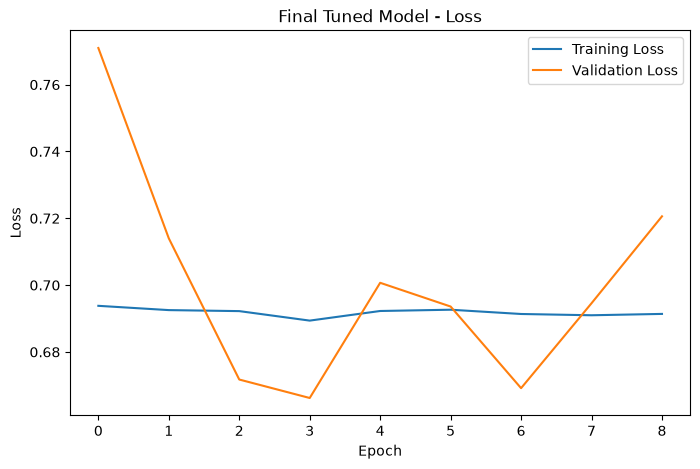

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(history_final.history["loss"], label="Training Loss")

plt.plot(history_final.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Tuned Model - Loss")
plt.legend()

plt.show()

**Final Loss Curve Interpretation**

The validation loss changes noticeably between epochs instead of decreasing smoothly.       
 EarlyStopping prevents the model from continuing to train when validation loss stops improving.        
  This helps reduce unnecessary training and limits additional overfitting.     

Training stopped before reaching the maximum 100 epochs because validation performance stopped improving.       

- Accuracy plot

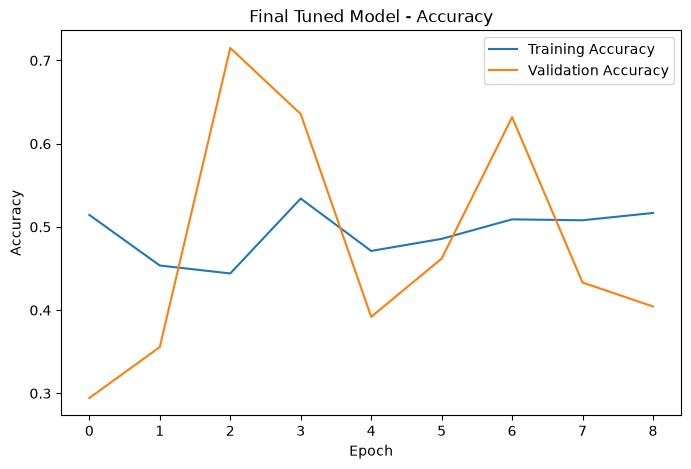

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(history_final.history["accuracy"],label="Training Accuracy")

plt.plot(history_final.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Tuned Model - Accuracy")
plt.legend()

plt.show()

**Final Accuracy Curve Interpretation**

Training and validation accuracy vary considerably during training.     
 This happens partly because class weights force the model to give more importance to the minority Yes class.       

Therefore, `accuracy is not the main metric used to judge this model.`      
 **`Recall and macro F1-score give a more useful view of performance on the imbalanced dataset`**.

- Recall plot

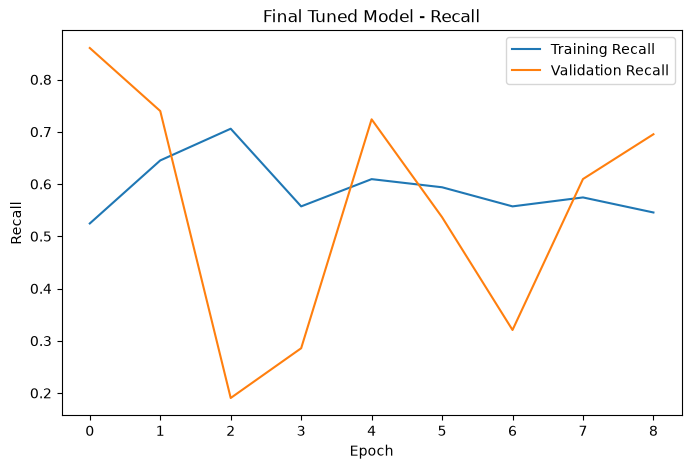

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(history_final.history["recall"], label="Training Recall")

plt.plot(history_final.history["val_recall"], label="Validation Recall")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Final Tuned Model - Recall")
plt.legend()

plt.show()

**Final Recall Curve Interpretation**

Recall changes considerably between epochs, showing that the model's ability to identify positive heart-disease cases is sensitive to the training state.

Class weighting prevents recall from collapsing completely to zero, but the final model still has difficulty consistently identifying the positive class.

#### Final test Evaluation:

**`Note`**: this is `not` the best model from check point, that was done in the modelcheckpoint section.

In [71]:
final_results = final_model.evaluate(X_test_processed, y_test_nn, return_dict= True)

print("Final test results: ")

for  metric, value in final_results.items():
    print (metric, ":", value)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6850 - loss: 0.6449 - precision: 0.2021 - recall: 0.1950        
Final test results: 
accuracy : 0.6850000023841858
loss : 0.6448737978935242
precision : 0.20207254588603973
recall : 0.19499999284744263


In [72]:
y_prob_final = final_model.predict( X_test_processed)

y_pred_final = ( y_prob_final >= 0.5).astype(int).ravel() # ravel()  flattenes a multi-dimensional array into a one-dimensional array

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [73]:

print( confusion_matrix(y_test_nn , y_pred_final))

print(classification_report(y_test_nn , y_pred_final , target_names=["No", "Yes"]))

print("Macro F1:", f1_score(y_test_nn , y_pred_final , average="macro"))

[[1292  308]
 [ 322   78]]
              precision    recall  f1-score   support

          No       0.80      0.81      0.80      1600
         Yes       0.20      0.20      0.20       400

    accuracy                           0.69      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.68      0.69      0.68      2000

Macro F1: 0.5012279293358731


**Final Test Evaluation**

The final tuned neural network achieved approximately 68.5% accuracy and a macro F1-score of 0.501.

For the positive Yes class, precision was approximately 0.20 and recall was approximately 0.195.        
 Out of 400 actual heart-disease cases, the model correctly identified 78 and missed 322.       

The final model therefore `performs more evenly across both classes than the original unbalanced models`, `but positive-class detection is still weak`.     
 The results also confirm that accuracy alone is not sufficient for evaluating this dataset.

### **Sprint 1 Overview:** 

#### Model comparison:

| Model                        |  Accuracy |  Macro F1 | Yes Precision | Yes Recall |
| ---------------------------- | --------: | --------: | ------------: | ---------: |
| Logistic Regression          |     0.800 |     0.444 |         0.000 |      0.000 |
| Balanced Logistic Regression |     0.504 |    ~0.456 |         0.190 |      0.458 |
| Regularized Neural Network   |     0.798 |     0.444 |         0.000 |      0.000 |
| Regularized + Balanced NN    |     0.518 |     0.463 |         0.207 |  **0.500** |
| Final Tuned NN               |     0.685 | **0.501** |         0.202 |      0.195 |
| Best Checkpoint Model        | **0.737** |     0.495 |     **0.208** |      0.112 |




**Model Comparison**

The original Logistic Regression and regularized neural-network models achieved around `80% accuracy`,      
 but both failed to detect the positive class because of the `80/20 class imbalance`.       

Applying class weighting improved minority-class detection.     
 The `regularized balanced neural network` achieved the ****highest**** `positive-class recall` at `0.50`.      

The `final tuned model` achieved the ****highest**** `macro F1-score` at approximately `0.501`,     
 while the `best checkpoint model` reached higher accuracy at `73.7%` but lower recall at `0.112`.      

Therefore, `there is a trade-off between the models`:       
 the final tuned model gives the best overall balance,      
  while the regularized balanced model is better when detecting more positive heart-disease cases is the priority.


#### Sprint 1 Conclusion


**Conclusion**

Sprint 1 established a Logistic Regression baseline and developed several neural-network models for heart-disease classification.

The `main challenge` discovered during the sprint `was the 80/20 class imbalance`.      
 Models that were not balanced could achieve approximately 80% accuracy simply by predicting mostly No, while producing almost zero recall for heart-disease cases.

Dropout and batch normalization helped control overfitting, while class weighting allowed the neural network to begin detecting the minority class.     
 Hyperparameter tuning and EarlyStopping were then used to improve training and select a final model.

The final tuned model achieved a macro F1-score of approximately 0.501, compared with approximately 0.444 for the original Logistic Regression baseline.        
 However, positive-class recall remains limited, leaving room for improvement in Sprint 2.

#### Limitations / Notes

**Limitations and Notes**

- The `dataset is strongly imbalanced`, with approximately 80% No and 20% Yes.

- `Accuracy can therefore be misleading` and should be considered together with precision, recall, F1-score, and the confusion matrix.

- The `models still have difficulty separating positive and negative heart-disease cases`.

- `Hyperparameter tuning results can vary` because `neural-network training contains randomness`.

- `Different metrics may favor different models`.       
 The balanced network produced better positive recall, while the final tuned model produced better macro F1 and accuracy.

- Future work should investigate decision-threshold tuning, additional features, alternative architectures, and other methods for handling imbalance.

#### Retrospective


**Sprint 1 Retrospective**

What went well

- A classical Logistic Regression baseline was successfully created.
- Neural-network forward propagation, training, regularization, and tuning were implemented.
- Training and validation curves helped identify overfitting.
- `Precision, recall, F1-score, and confusion matrices` **`revealed the class-imbalance problem`** that `accuracy alone did not show.`
- Class weighting, dropout, batch normalization, EarlyStopping, and ModelCheckpoint were successfully tested


What could be improved

- Hyperparameter experiments should use one clearly defined model-selection metric.
- Experiment configurations and results should be recorded in one table from the beginning.